In [1]:
# Core LSD imports
from sclsd.train import LSD

from sclsd.core import LSDConfig
# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import torch

# Single-cell analysis
import scanpy as sc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#read the adata
data_path = "../../Zenodo/BoneMarrow/preprocessed_adata.h5ad"
adata = sc.read(data_path)

#intialize LSD model
cfg = LSDConfig()
lsd = LSD(
    adata,
    cfg,
    device=device,
)

#load the trained model
model_dir = "../BoneMarrow/model"
model_path = "lsd_model_epoch0200.pth"
lsd.load(model_dir, model_path)

#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 5, cluster_key = "clusters", batch_size= 2048)

[LSD] Model and Pyro parameters loaded from ../BoneMarrow/model/lsd_model_epoch0200.pth


Batch Propagation:   0%|          | 0/3 [00:00<?, ?it/s]

Batch Propagation:  33%|███▎      | 1/3 [00:03<00:07,  3.59s/it]

Batch Propagation:  67%|██████▋   | 2/3 [00:05<00:02,  2.74s/it]

Batch Propagation: 100%|██████████| 3/3 [00:07<00:00,  2.51s/it]

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/sclsd/train/trainer.py:894: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_fates = adata.obs[cluster_key][nn.cpu().numpy()].values


In [3]:
cbdir_df = pd.read_csv("../../csvs/UnseenBoneMarrow/cbdir_seen_vs_unseen/cbdir_seen_vs_unseen.csv")
fatebtstrp_df = pd.read_csv("../../csvs/UnseenBoneMarrow/bootstrap_correlation_results_LOC_fateMonoMerged.csv")

In [4]:
fatebtstrp_df

,excluded_cluster,model_name,bootstrap_id,correlation
0,HSC_1,LOC_HSC_1,1,0.861414
1,HSC_1,LOC_HSC_1,2,0.827303
2,HSC_1,LOC_HSC_1,3,0.845813
3,HSC_1,LOC_HSC_1,4,0.853258
4,HSC_1,LOC_HSC_1,5,0.819240
...,...,...,...,...
3995,Ery_2,LOC_Ery_2,496,0.924996
3996,Ery_2,LOC_Ery_2,497,0.837751
3997,Ery_2,LOC_Ery_2,498,0.919312
3998,Ery_2,LOC_Ery_2,499,0.885524


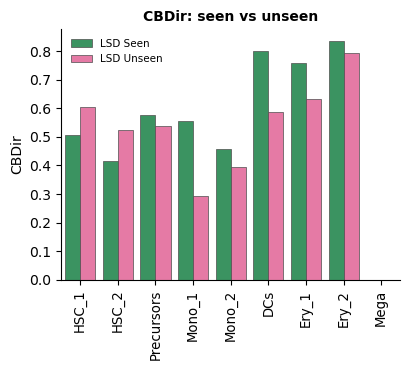

In [5]:
#Barplot: seen (green) vs unseen (pink) CBDir per cluster
from pathlib import Path

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"   # keep SVG text selectable/editable


def save_fig(fig, name):
    for ext in ("svg", "png"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")


bars = cbdir_df[cbdir_df["Cluster"] != "Mean"].melt(
    id_vars="Cluster", value_vars=["LSD Seen", "LSD Unseen"],
    var_name="Condition", value_name="CBDir",
)

fig, ax = plt.subplots(figsize=(4.2, 3.8))
sns.barplot(data=bars, x="Cluster", y="CBDir", hue="Condition",
            palette={"LSD Seen": "#2ca25f", "LSD Unseen": "#f768a1"},
            edgecolor="0.3", linewidth=0.5, ax=ax)
ax.set_title("CBDir: seen vs unseen", fontsize=10, fontweight="semibold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=90, labelsize=9.6)
ax.legend(frameon=False, fontsize=7.5, title=None)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, "cbdir_seen_vs_unseen")
plt.show()

In [6]:
# Merge Mono_1 + Mono_2 -> Mono. Keep {Mono, DCs, Ery_2, Mega} as the fate pool.
# Every remaining cell is assigned a fate by majority vote of its K nearest
# neighbours (X_pca) within that pool, then scored against the LSD fate.

from sklearn.neighbors import NearestNeighbors

K = 15
FATES = np.array(["Mono", "DCs", "Ery_2", "Mega"])

merge = lambda s: pd.Series(s.astype(str).to_numpy()).replace({"Mono_1": "Mono", "Mono_2": "Mono"}).to_numpy()
clusters = merge(dyn_adata.obs["clusters"])
truth = merge(dyn_adata.obs["fate"])

CLUSTER_COLORS = dict(zip(dyn_adata.obs["clusters"].cat.categories, dyn_adata.uns["clusters_colors"]))
CLUSTER_COLORS["Mono"] = CLUSTER_COLORS["Mono_1"]

pool = np.isin(clusters, FATES)   # reference cells carrying a fate identity
rest = ~pool                      # cells needing an assignment
P = dyn_adata.obsm["X_pca"]

_, idx = NearestNeighbors(n_neighbors=K).fit(P[pool]).kneighbors(P[rest])
nbr = clusters[pool][idx]                                   # (n_rest, K) neighbour labels
frac = np.stack([(nbr == f).mean(1) for f in FATES], 1)     # soft vote over the 4 fates
assigned = FATES[frac.argmax(1)]                            # majority vote


def rowwise_corr(A, B):
    """Per-cell Pearson r between two row vectors."""
    A = A - A.mean(1, keepdims=True)
    B = B - B.mean(1, keepdims=True)
    return (A * B).sum(1) / np.sqrt((A ** 2).sum(1) * (B ** 2).sum(1))


E = (FATES[None, :] == truth[rest][:, None]).astype(float)  # one-hot LSD fate
valid = E.sum(1) > 0                                        # scorable only if LSD fate is one of the 4

knn_df = pd.DataFrame({
    "cluster": clusters[rest][valid],
    "assigned_fate": assigned[valid],
    "lsd_fate": truth[rest][valid],
    "correlation": rowwise_corr(frac[valid], E[valid]),
})
print(f"assigned {rest.sum()} cells | scored {valid.sum()} "
      f"({(~valid).sum()} dropped: LSD fate outside {FATES.tolist()}) | "
      f"overall agreement {(knn_df.assigned_fate == knn_df.lsd_fate).mean():.3f}")

knn_stats = knn_df.groupby("cluster")["correlation"].describe()
knn_stats

assigned 3510 cells | scored 3389 (121 dropped: LSD fate outside ['Mono', 'DCs', 'Ery_2', 'Mega']) | overall agreement 0.390


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
Ery_1,708.0,0.910659,0.294942,-0.665750,0.997629,1.000000,1.000000,1.0
HSC_1,1070.0,-0.038998,0.489744,-0.714286,-0.333333,-0.267657,0.037037,1.0
HSC_2,956.0,0.079064,0.549697,-0.756650,-0.333333,-0.267657,0.651441,1.0
Precursors,655.0,0.173955,0.593663,-0.574801,-0.333333,-0.187016,0.998814,1.0


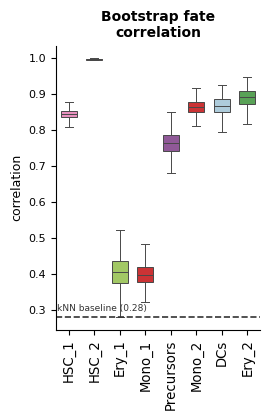

In [7]:
#Bootstrap fate correlation per excluded cluster, with the kNN baseline overlaid
knn_baseline = knn_stats["mean"].mean()   # mean of the four per-cluster kNN means

order = [c for c in dyn_adata.obs["clusters"].cat.categories
         if c in set(fatebtstrp_df["excluded_cluster"])]

fig, ax = plt.subplots(figsize=(2.8, 4.3))
sns.boxplot(data=fatebtstrp_df, x="excluded_cluster", y="correlation", order=order,
            hue="excluded_cluster", palette=CLUSTER_COLORS, legend=False,
            width=0.62, linewidth=0.7, showfliers=False, ax=ax)
ax.axhline(knn_baseline, color="0.2", ls="--", lw=1.2)
ax.text(-0.45, knn_baseline + 0.012, f"kNN baseline ({knn_baseline:.2f})",
        fontsize=6.5, color="0.2", va="bottom", ha="left")
ax.set_title("Bootstrap fate\ncorrelation", fontsize=10, fontweight="semibold")
ax.set_xlabel("")
ax.set_ylabel("correlation", fontsize=9)
ax.tick_params(axis="x", rotation=90, labelsize=9.6)
ax.tick_params(axis="y", labelsize=8)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, "bootstrap_fate_correlation")
plt.show()

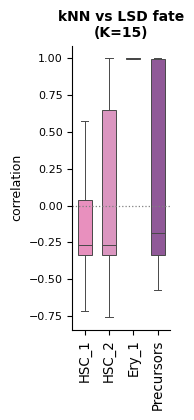

In [8]:
#Per-cell correlation between the kNN-assigned fate and the LSD fate
order = [c for c in dyn_adata.obs["clusters"].cat.categories if c in set(knn_df["cluster"])]

fig, ax = plt.subplots(figsize=(1.9, 4.3))
sns.boxplot(data=knn_df, x="cluster", y="correlation", order=order,
            hue="cluster", palette=CLUSTER_COLORS, legend=False,
            width=0.58, linewidth=0.7, showfliers=False, ax=ax)
ax.axhline(0, color="0.5", ls=":", lw=0.9)
ax.set_title(f"kNN vs LSD fate\n(K={K})", fontsize=10, fontweight="semibold")
ax.set_xlabel("")
ax.set_ylabel("correlation", fontsize=9)
ax.tick_params(axis="x", rotation=90, labelsize=9.6)
ax.tick_params(axis="y", labelsize=8)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, "knn_vs_lsd_fate")
plt.show()

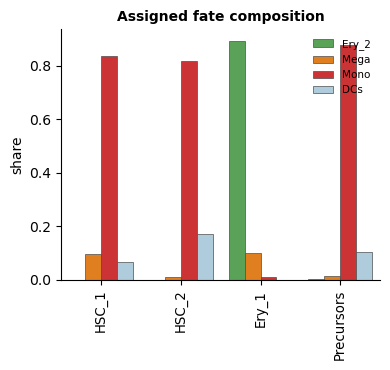

In [9]:
#Composition of the kNN-assigned fates for each originating cluster
share = (knn_df.groupby("cluster")["assigned_fate"].value_counts(normalize=True)
               .rename("share").reset_index())

fig, ax = plt.subplots(figsize=(4.0, 3.8))
sns.barplot(data=share, x="cluster", y="share", hue="assigned_fate",
            order=order, palette=CLUSTER_COLORS,
            edgecolor="0.3", linewidth=0.5, ax=ax)
ax.set_title("Assigned fate composition", fontsize=10, fontweight="semibold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=90, labelsize=9.6)
ax.legend(frameon=False, fontsize=7.5, title=None)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, "assigned_fate_composition")
plt.show()